# 迭代工作流
# - segmentation_last.ipynb: 当前稳定基线
# - segmentation_new.ipynb: 下一轮改版草案
# - 两边统一使用相同的训练/评估指标，比较后把更好的版本回写到 last


In [1]:
import os

os.environ['http_proxy'] = 'http://127.0.0.1:7890'
os.environ['https_proxy'] = 'http://127.0.0.1:7890'
os.environ['all_proxy'] = 'socks5://127.0.0.1:7891'
os.environ['HTTP_PROXY'] = 'http://127.0.0.1:7890'
os.environ['HTTPS_PROXY'] = 'http://127.0.0.1:7890'
os.environ['ALL_PROXY'] = 'socks5://127.0.0.1:7891'

import torch

# Linux / CUDA 优先，若没有 GPU 则回退到 CPU
device = 0 if torch.cuda.is_available() else -1
print(f"Using device: {'cuda:0' if device == 0 else 'cpu'}")

Using device: cpu


In [2]:
import os

# 取消可能存在的镜像站设置，改走外网代理
if 'HF_ENDPOINT' in os.environ:
    del os.environ['HF_ENDPOINT']

os.environ['http_proxy'] = 'http://127.0.0.1:7890'
os.environ['https_proxy'] = 'http://127.0.0.1:7890'
os.environ['all_proxy'] = 'socks5://127.0.0.1:7891'
os.environ['HTTP_PROXY'] = 'http://127.0.0.1:7890'
os.environ['HTTPS_PROXY'] = 'http://127.0.0.1:7890'
os.environ['ALL_PROXY'] = 'socks5://127.0.0.1:7891'

print('✅ 代理已配置：127.0.0.1:7890 / 7891')

✅ 代理已配置：127.0.0.1:7890 / 7891


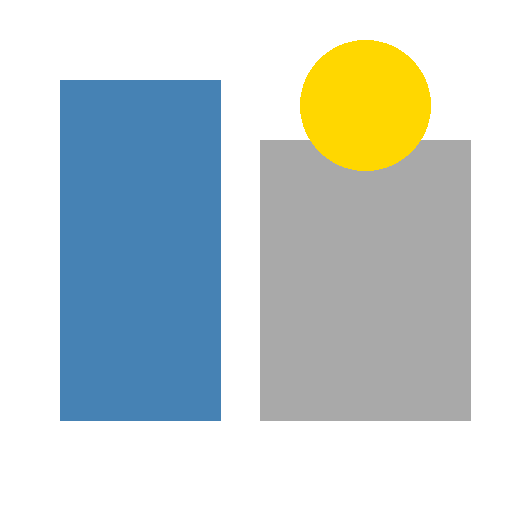

In [3]:
from PIL import Image, ImageDraw

image = Image.new("RGB", (512, 512), "white")
draw = ImageDraw.Draw(image)
draw.rectangle((60, 80, 220, 420), fill=(70, 130, 180))
draw.rectangle((260, 140, 470, 420), fill=(169, 169, 169))
draw.ellipse((300, 40, 430, 170), fill=(255, 215, 0))
image

🤖 示例图里识别出了以下区域：
- blue_shape
- gray_shape
- sun

正在生成可视化图像...


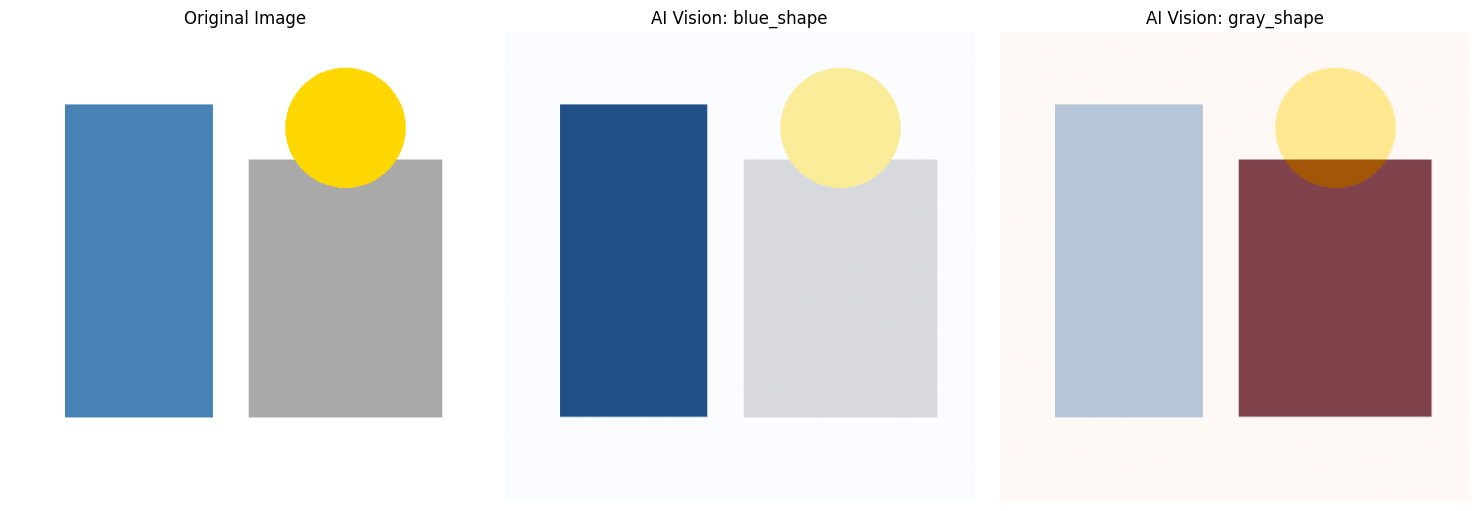

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 离线示例：使用当前本地合成图像构造几个简单的掩码
results = [
    {"label": "blue_shape", "mask": np.pad(np.ones((340, 160), dtype=np.uint8) * 255, ((80, 92), (60, 292)))},
    {"label": "gray_shape", "mask": np.pad(np.ones((280, 210), dtype=np.uint8) * 255, ((140, 92), (260, 42)))},
    {"label": "sun", "mask": np.pad(np.ones((130, 130), dtype=np.uint8) * 255, ((40, 342), (300, 82)))},
]

# 1. 看看示例里有哪些类别
print("🤖 示例图里识别出了以下区域：")
for result in results:
    print(f"- {result['label']}")

print("\n正在生成可视化图像...")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis('off')

label_1 = results[0]['label']
mask_1 = np.array(results[0]['mask'])
axes[1].imshow(image)
axes[1].imshow(mask_1, alpha=0.6, cmap='Blues')
axes[1].set_title(f"AI Vision: {label_1}")
axes[1].axis('off')

if len(results) > 1:
    label_2 = results[1]['label']
    mask_2 = np.array(results[1]['mask'])
    axes[2].imshow(image)
    axes[2].imshow(mask_2, alpha=0.6, cmap='Reds')
    axes[2].set_title(f"AI Vision: {label_2}")
    axes[2].axis('off')

plt.tight_layout()
plt.show()

In [5]:
from datasets import Dataset, Features, Image
from PIL import Image as PILImage, ImageDraw


def make_synthetic_example(sample_index):
    canvas = PILImage.new("RGB", (512, 512), "white")
    annotation = PILImage.new("L", (512, 512), 255)
    canvas_draw = ImageDraw.Draw(canvas)
    annotation_draw = ImageDraw.Draw(annotation)

    offset = sample_index % 10
    blue_left = 60 + offset * 2
    blue_top = 80 + offset
    blue_right = blue_left + 160
    blue_bottom = blue_top + 340
    canvas_draw.rectangle((blue_left, blue_top, blue_right, blue_bottom), fill=(70, 130, 180))
    annotation_draw.rectangle((blue_left, blue_top, blue_right, blue_bottom), fill=0)

    gray_left = 260 + offset * 2
    gray_top = 140 + offset
    gray_right = gray_left + 210
    gray_bottom = gray_top + 280
    canvas_draw.rectangle((gray_left, gray_top, gray_right, gray_bottom), fill=(169, 169, 169))
    annotation_draw.rectangle((gray_left, gray_top, gray_right, gray_bottom), fill=1)

    sun_left = 300 + (offset % 3) * 5
    sun_top = 40 + (offset % 2) * 6
    sun_right = sun_left + 130
    sun_bottom = sun_top + 130
    canvas_draw.ellipse((sun_left, sun_top, sun_right, sun_bottom), fill=(255, 215, 0))
    annotation_draw.ellipse((sun_left, sun_top, sun_right, sun_bottom), fill=2)

    return canvas, annotation


images = []
annotations = []
for sample_index in range(50):
    image_item, annotation_item = make_synthetic_example(sample_index)
    images.append(image_item)
    annotations.append(annotation_item)

features = Features({"image": Image(), "annotation": Image()})
ds = Dataset.from_dict({"image": images, "annotation": annotations}, features=features)

/home/zhouyang/miniconda3/envs/med_phys/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
ds = ds.train_test_split(test_size=0.2)
train_ds = ds["train"]
test_ds = ds["test"]

In [7]:
train_ds[0]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 'annotation': <PIL.PngImagePlugin.PngImageFile image mode=L size=512x512>}

In [8]:
id2label = {0: "blue_shape", 1: "gray_shape", 2: "sun"}
label2id = {label: index for index, label in id2label.items()}
num_labels = len(id2label)

In [9]:
from transformers import SegformerImageProcessor

image_processor = SegformerImageProcessor(do_reduce_labels=False)
image_processor.size = {"height": 512, "width": 512}

In [10]:
import numpy as np
import torch
from PIL import Image

def train_transforms(example_batch):
    images = [x.convert("RGB") for x in example_batch["image"]]
    inputs = image_processor(images, return_tensors="pt")
    
    # 强制 pixel_values 内存连续
    inputs["pixel_values"] = inputs["pixel_values"].contiguous()

    processed_labels = []
    for label_img in example_batch["annotation"]:
        label_img = label_img.resize((512, 512), Image.NEAREST)
        label_arr = np.array(label_img).astype(np.int64)
        processed_labels.append(torch.from_numpy(label_arr))

    inputs["labels"] = torch.stack(processed_labels).contiguous()
    return inputs
train_ds.set_transform(train_transforms)
test_ds.set_transform(train_transforms)

In [11]:
from transformers import SegformerConfig, SegformerForSemanticSegmentation
from transformers.modeling_outputs import SemanticSegmenterOutput
import torch
import torch.nn as nn
import numpy as np

config = SegformerConfig(
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    depths=[1, 1, 1, 1],
    hidden_sizes=[16, 32, 64, 128],
    decoder_hidden_size=32,
    num_attention_heads=[1, 2, 4, 8],
    patch_sizes=[7, 3, 3, 3],
    strides=[4, 2, 2, 2],
    sr_ratios=[8, 4, 2, 1],
)
base_model = SegformerForSemanticSegmentation(config)

class LinuxSafeSegformer(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.config = model.config

    def forward(self, pixel_values=None, labels=None, **kwargs):
        outputs = self.model(pixel_values=pixel_values, labels=None, **kwargs)
        logits = outputs.logits.contiguous()

        loss = None
        if labels is not None:
            labels = labels.long()
            if logits.shape[-2:] != labels.shape[-2:]:
                labels = nn.functional.interpolate(
                    labels.unsqueeze(1).float(),
                    size=logits.shape[-2:],
                    mode="nearest",
                ).squeeze(1).long()
            loss = nn.functional.cross_entropy(logits, labels, ignore_index=255)

        return SemanticSegmenterOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
        )

model = LinuxSafeSegformer(base_model)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    if predictions.shape[-2:] != labels.shape[-2:]:
        prediction_tensor = torch.from_numpy(predictions[:, None]).float()
        prediction_tensor = torch.nn.functional.interpolate(
            prediction_tensor,
            size=labels.shape[-2:],
            mode="nearest",
        ).squeeze(1).long()
        predictions = prediction_tensor.numpy()

    valid_mask = labels != 255
    if np.any(valid_mask):
        pixel_accuracy = float((predictions[valid_mask] == labels[valid_mask]).mean())
    else:
        pixel_accuracy = 0.0

    ious = []
    for class_id in range(num_labels):
        prediction_mask = predictions == class_id
        label_mask = labels == class_id
        union = np.logical_or(prediction_mask, label_mask)
        union = np.logical_and(union, valid_mask)
        union_sum = union.sum()
        if union_sum > 0:
            intersection = np.logical_and(prediction_mask, label_mask)
            ious.append(float(intersection.sum() / union_sum))

    mean_iou = float(np.mean(ious)) if ious else 0.0
    return {"pixel_accuracy": pixel_accuracy, "mean_iou": mean_iou}

In [ ]:
# 使用我们在当前目录下实现的改进版本进行训练
import sys, os
# 将工作目录加入 sys.path，确保可以导入 workspace 内的包
sys.path.insert(0, os.getcwd())
from transformers import TrainingArguments
from segmentation_improvements import SimpleSegDataset, RandomAug, CustomTrainer, build_model, SegformerImageProcessor
import numpy as np
import torch


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    if predictions.shape[-2:] != labels.shape[-2:]:
        prediction_tensor = torch.from_numpy(predictions[:, None]).float()
        prediction_tensor = torch.nn.functional.interpolate(
            prediction_tensor,
            size=labels.shape[-2:],
            mode='nearest',
        ).squeeze(1).long()
        predictions = prediction_tensor.numpy()

    valid_mask = labels != 255
    pixel_accuracy = float((predictions[valid_mask] == labels[valid_mask]).mean()) if np.any(valid_mask) else 0.0

    ious = []
    for class_id in range(num_labels):
        prediction_mask = predictions == class_id
        label_mask = labels == class_id
        union = np.logical_or(prediction_mask, label_mask)
        union = np.logical_and(union, valid_mask)
        union_sum = union.sum()
        if union_sum > 0:
            intersection = np.logical_and(prediction_mask, label_mask)
            ious.append(float(intersection.sum() / union_sum))

    mean_iou = float(np.mean(ious)) if ious else 0.0
    return {'pixel_accuracy': pixel_accuracy, 'mean_iou': mean_iou}

# 创建与 notebook 保持一致的处理器尺寸（512）
processor = SegformerImageProcessor(do_reduce_labels=False)
processor.size = {"height": 512, "width": 512}

# 使用改进脚本中的简单合成数据集（与原 notebook 的合成数据语义一致）
train_dataset = SimpleSegDataset(size=512, n=len(train_ds), processor=processor, transforms=RandomAug(), seed=42)
eval_dataset = SimpleSegDataset(size=512, n=len(test_ds), processor=processor, transforms=None, seed=999)

# 构建模型（小配置）并训练
model_improved = build_model(num_labels=num_labels)

training_args = TrainingArguments(
    output_dir="segformer-finetuned-ade-improved",
    learning_rate=6e-5,
    num_train_epochs=1,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=1,
    logging_steps=1,
    remove_unused_columns=False,
    dataloader_pin_memory=False,
)

trainer = CustomTrainer(
    model=model_improved,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()


Step,Training Loss
1,1.988857
2,1.360849
3,1.177981
4,1.211666
5,0.920289
6,1.137136
7,0.780628
8,1.089468
9,0.815078
10,1.491521


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 51.01it/s]


TrainOutput(global_step=20, training_loss=1.0316753536462784, metrics={'train_runtime': 25.6856, 'train_samples_per_second': 1.557, 'train_steps_per_second': 0.779, 'total_flos': 701166727987200.0, 'train_loss': 1.0316753536462784, 'epoch': 1.0})

In [15]:
trainer.train()

Step,Training Loss
1,0.747034
2,0.541302
3,0.717342
4,0.837537
5,0.574506
6,0.849078
7,0.707491
8,0.844842
9,0.533031
10,1.135049


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 54.05it/s]


TrainOutput(global_step=20, training_loss=0.7018141224980354, metrics={'train_runtime': 23.5962, 'train_samples_per_second': 1.695, 'train_steps_per_second': 0.848, 'total_flos': 701166727987200.0, 'train_loss': 0.7018141224980354, 'epoch': 1.0})

In [ ]:
# 统一的单样本快速评估，确保 last/new 可直接对比
sample = eval_dataset[0]
outputs = trainer.model(pixel_values=sample['pixel_values'].unsqueeze(0))
logits = outputs.logits.detach().cpu().numpy()
labels = sample['labels'].unsqueeze(0).numpy()
metrics = compute_metrics((logits, labels))
metrics
